# Introduction to Machine Learning (CSCI-UA.473)

### Programming Assignment 1: Linear Models
#### Due: October 3, 2025 at 11:59PM


#### Name:
#### Email:

##### You may not use any additional libraries other than what is included in the import statements below. You may only use the train test split functionality from scipy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

### Z Disease Dataset

The Z dataset contains ten baseline variables (age, sex, BMI, average blood pressure, and six blood serum measurements) and a quantitative measure of disease progression one year after baseline. Specifically, it comprises a total of 442 samples, where each sample has 10 input features and a target value representing the quantitative measure of disease Z progression.

In [2]:
# Load the entire dataset from the CSV file
# If you are running the code locally, you should do:
# hw_data = os.getcwd() + 'hw1_dataset.csv')
# data = pd.read_csv(hw_data)

# If you are running the code on colab, you should do:
from google.colab import drive
drive.mount('/content/drive/')
hw_data = os.getcwd() + '/drive/My Drive/ML473/HW1/hw1_dataset.csv' # note: you may need to update this with your path!!
data = pd.read_csv(hw_data)

# Separate the features, target values, and feature names
X = data.drop('target', axis=1)
y = data['target'].values
feature_names = X.columns.tolist()

Mounted at /content/drive/


In [ ]:
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### Question 1: Data Visualization (15 points)
**Task 1.1 (5 points):** Create a scatter plot to visualize the relationship between BMI (Body Mass Index) and disease Z progression.

* Analyze the scatter plot and describe whether there appears to be a positive or negative correlation, or if no clear correlation is evident. Explain your answer in a couple of sentences.
* Can we confidently infer a person's disease Z status using BMI as the only input variable? Explain your reasoning and any potential caveats.

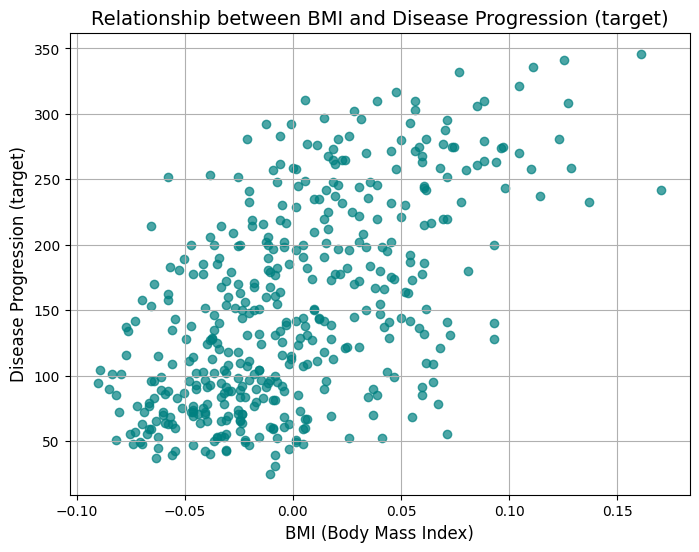

In [ ]:
# Your answer here
import matplotlib.pyplot as plt

# Scatter plot of BMI vs target
plt.figure(figsize=(8, 6))
plt.scatter(data['bmi'], data['target'], alpha=0.7, color='teal')
plt.title('Relationship between BMI and Disease Progression (target)', fontsize=14)
plt.xlabel('BMI (Body Mass Index)', fontsize=12)
plt.ylabel('Disease Progression (target)', fontsize=12)
plt.grid(True)
plt.show()


There appears to be a moderate positive correlation between BMI and disease progression (target). As BMI increases, the disease progression scores also tend to be higher. This suggests that higher BMI values might be associated with worse outcomes for disease Z.
However, we can not confidently estimate the disease progression with only BMI, becuase this may cause underfitting. One variable can not help the model catch all the variaion in target output, oversimplified model may cause larger errors.

**Task 1.2 (5 points):** Create a histogram to visualize the distribution of age among Z patients. Choose 20 as the number of bins in the histogram.

* Which bin in the histogram has the highest frequency?
* What distribution does the histogram most resemble?

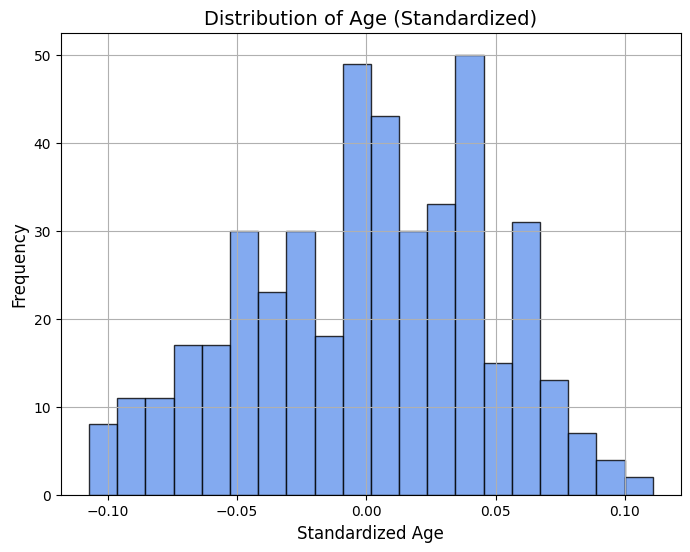

In [ ]:
# Your answer here
import matplotlib.pyplot as plt

# Plot histogram of the 'age' feature
plt.figure(figsize=(8, 6))
plt.hist(data['age'], bins=20, color='cornflowerblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Age (Standardized)', fontsize=14)
plt.xlabel('Standardized Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True)
plt.show()


The bin centered around 0.05 (i.e., standardized age slightly above the mean) has the highest frequency, with a count of approximately 50 patients.
The histogram closely resembles a normal distribution (Gaussian curve)—it is approximately symmetric, bell-shaped, and centered around 0. This is consistent with what we expect from standardized features, which are typically transformed to have a mean of 0 and unit variance.

**Task 1.3 (5 points):** The box plot is a graphical representation that allows you to visually assess the distribution of values and identify potential differences between the two groups. If you're unfamiliar with box plots or need further guidance, you can refer to this [resource](https://www.data-to-viz.com/caveat/boxplot.html) on box plots for a detailed explanation and examples.

Construct a box plot to compare the progression of Z in male and female patients. You can treat sex > 0 as female and sex < 0 as male.

* How does the progression differ between males and females, as revealed by the box plot?
* In particular, are the 25th, 50th, and 75th percentiles the same or different?

/tmp/ipython-input-1182220743.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex_label', y='target', data=data, palette='Set2')


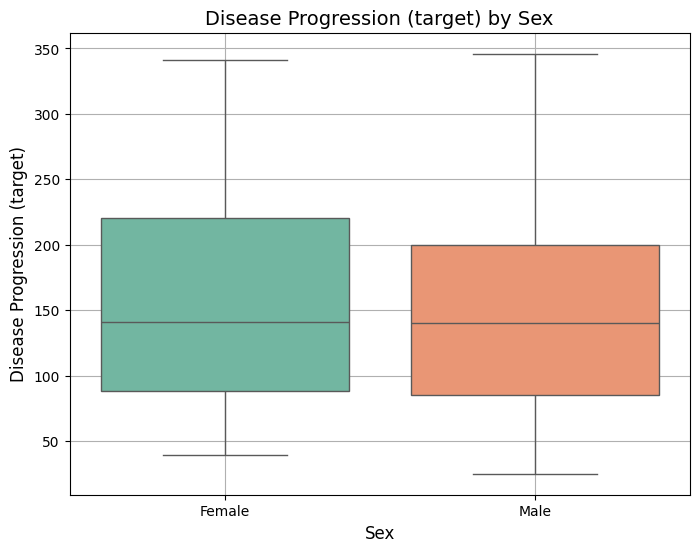

In [ ]:
# Your answer here
import seaborn as sns
import matplotlib.pyplot as plt

# Create a new column 'sex_label' for grouping
data['sex_label'] = data['sex'].apply(lambda x: 'Female' if x > 0 else 'Male')

# Create box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='sex_label', y='target', data=data, palette='Set2')
plt.title('Disease Progression (target) by Sex', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Disease Progression (target)', fontsize=12)
plt.grid(True)
plt.show()


### Question 2: Linear, Ridge, and Lasso Regression (8 points)

**Task 2.1 (2 points):** Split the dataset into training and testing sets (80/20\%) split.

In [4]:
# Your answer here
from sklearn.model_selection import train_test_split

# Split dataset into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Task 2.2 (2 points):** Linear regression

A linear regression model is a linear function of the parameters of the model. Its output $y$ is a real number or a real vector, depending on the task definition. That is:
$$\beta = \underset{\beta}{\text{argmin}}\sum_{i=1}^n\left(Y_i - X_i \beta\right)^2$$


* $X_i = [X_1^{(1)}\ldots X_i^{(p)}]$
* $\beta_0,\ldots,\beta_p$ are the coefficients for the features.
* $x_{ji}$ represents the values of the j-th feature for the i-th observation.
* $y_i$ is the target value for the i-th observation.

Fit the data using linear regression. Report the intercept, coefficients, and MSE.

In [ ]:
# Your answer here
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Initialize and fit linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred = lin_reg.predict(X_test)

# Metrics
intercept = lin_reg.intercept_
coefficients = lin_reg.coef_
mse = mean_squared_error(y_test, y_pred)

print("Intercept:", intercept)
print("Coefficients:", coefficients)
print("MSE:", mse)


Intercept: 151.34560453985995
Coefficients: [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]
MSE: 2900.193628493483


**Task 2.3 (2 points) :** Ridge Regression is a regularized linear regression with an added L2 regularization term to the linear regression cost function. This regularization is useful because there could be instability in training (e.g., there could be many correlated features). At a high level, the L2 regularization tries to spread the influence more evenly across the features.

$$\beta = \underset{\beta}{\text{argmin}}\sum_{i=1}^n\left(Y_i - X_i \beta\right)^2 + \lambda \|\beta\|^2_2$$

* $\lambda$ is the regularization hyper-parameter.

Implement ridge regression and report the intercept, coefficients, and MSE.

In [ ]:
# Your answer here
from sklearn.linear_model import Ridge

# Initialize Ridge regression with a chosen alpha (λ)
ridge_reg = Ridge(alpha=1.0)   # λ = 1.0 by default
ridge_reg.fit(X_train, y_train)

# Predictions
y_pred_ridge = ridge_reg.predict(X_test)

# Metrics
ridge_intercept = ridge_reg.intercept_
ridge_coefficients = ridge_reg.coef_
ridge_mse = mean_squared_error(y_test, y_pred_ridge)

print("Intercept:", ridge_intercept)
print("Coefficients:", ridge_coefficients)
print("MSE:", ridge_mse)


Intercept: 152.241675211113
Coefficients: [  45.36737726  -76.66608563  291.33883165  198.99581745   -0.53030959
  -28.57704987 -144.51190505  119.26006559  230.22160832  112.14983004]
MSE: 3077.41593882723


**Task 2.4 (2 points):** LASSO Regression is a regularized linear regression with an added L1 regularization term to the linear regression cost function.
The idea behind LASSO is to enforce sparsity, where the model uses a small number of input features for prediction. The intuition is, if there are a large number of input features that might lead to the model overfitting (i.e., memorizing the data), then we may want to shrink some of the coefficients toward 0, meaning the model would effectively not use that subset of features for prediction.

$$\beta = \underset{\beta}{\text{argmin}}\sum_{i=1}^n\left(Y_i - X_i \beta\right)^2 + \lambda |\beta|$$

For more reading about LASSO, you can check [this reference](https://webdoc.agsci.colostate.edu/koontz/arec-econ535/papers/Tibshirani%20(JRSS-B%201996).pdf).

Implement Lasso regression and report the Lasso intercept, coefficients, and MSE.

In [ ]:
# Your answer here
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# ---------- Option A: fixed alpha ----------
lasso = Lasso(alpha=0.1, max_iter=10000, random_state=42)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
lasso_intercept = lasso.intercept_
lasso_coef = lasso.coef_
lasso_mse = mean_squared_error(y_test, y_pred_lasso)

print("LASSO (alpha=0.1)")
print("Intercept:", lasso_intercept)
print("MSE:", lasso_mse)
print(pd.Series(lasso_coef, index=feature_names, name="coef").round(4))

# ---------- Option B: choose alpha by CV ----------
alphas = np.logspace(-3, 1, 60)   # 0.001 ... 10
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train, y_train)
y_pred_lasso_cv = lasso_cv.predict(X_test)
lasso_cv_mse = mean_squared_error(y_test, y_pred_lasso_cv)

print("\nLASSO with CV")
print("Best alpha:", lasso_cv.alpha_)
print("Intercept:", lasso_cv.intercept_)
print("MSE:", lasso_cv_mse)
print(pd.Series(lasso_cv.coef_, index=feature_names, name="coef").round(4))

# (optional) how many features were selected
nz = np.sum(lasso_cv.coef_ != 0)
print(f"Non-zero coefficients: {nz}/{len(feature_names)}")


LASSO (alpha=0.1)
Intercept: 151.57485282893947
MSE: 2798.1934851697197
age      0.0000
sex   -152.6648
bmi    552.6978
bp     303.3652
s1     -81.3650
s2      -0.0000
s3    -229.2558
s4       0.0000
s5     447.9195
s6      29.6426
Name: coef, dtype: float64

LASSO with CV
Best alpha: 0.07912342618981323
Intercept: 151.52159898442378
MSE: 2800.113667701342
age      0.0000
sex   -167.4678
bmi    554.0701
bp     311.2578
s1    -100.9407
s2      -0.0000
s3    -234.8728
s4       0.0000
s5     460.0158
s6      36.5945
Name: coef, dtype: float64
Non-zero coefficients: 7/10


In [5]:
import numpy as np

def lasso_cd(X, y, alpha, max_iter=1000, tol=1e-6, fit_intercept=True, standardize=True):
    X = np.asarray(X, float); y = np.asarray(y, float)
    n, d = X.shape

    # standardize features (intercept handled separately)
    if standardize:
        X_mean, X_std = X.mean(0), X.std(0, ddof=0)
        Xs = (X - X_mean) / np.where(X_std==0, 1.0, X_std)
    else:
        Xs = X.copy()
        X_mean = np.zeros(d); X_std = np.ones(d)

    if fit_intercept:
        y_mean = y.mean()
        yc = y - y_mean
    else:
        y_mean = 0.0
        yc = y

    w = np.zeros(d)
    for _ in range(max_iter):
        w_old = w.copy()
        # cyclic coordinate updates
        for j in range(d):
            r_j = yc - (Xs @ w) + Xs[:, j]*w[j]         # partial residual
            rho = (Xs[:, j] * r_j).sum() / n
            zj = (Xs[:, j]**2).sum() / n
            # soft-thresholding
            if rho < -alpha:
                w[j] = (rho + alpha) / zj
            elif rho > alpha:
                w[j] = (rho - alpha) / zj
            else:
                w[j] = 0.0
        if np.linalg.norm(w - w_old, ord=np.inf) < tol:
            break

    # recover intercept/coef in original scale
    coef = w / np.where(X_std==0, 1.0, X_std)
    intercept = y_mean - (X_mean * coef).sum() if fit_intercept else 0.0
    return intercept, coef

# run it
alpha = 0.1
b0, coef = lasso_cd(X_train, y_train, alpha=alpha)
y_pred = X_test @ coef + b0
mse = ((y_test - y_pred)**2).mean()
nz = int((coef != 0).sum())

print("LASSO (from scratch, CD)")
print("alpha:", alpha, "| MSE:", mse, "| non-zero:", nz, "/", len(coef))
print(pd.Series(coef, index=feature_names, name="coef").round(4))


LASSO (from scratch, CD)
alpha: 0.1 | MSE: 2884.6855325802435 | non-zero: 10 / 10
age     37.3931
sex   -237.8596
bmi    547.0031
bp     343.9016
s1    -617.1820
s2     280.6147
s3      12.5297
s4     214.7613
s5     621.1810
s6      49.5344
Name: coef, dtype: float64


### Question 3: Model Analysis (15 points)

**Task 3.1 (5 points):** Visualize the coefficients of the Linear, Ridge, and Lasso models.
- What will be the impact of increase in the strength of s1 in linear regression?
- Among the three models, which one exhibits a more pronounced reliance on the BMI feature?

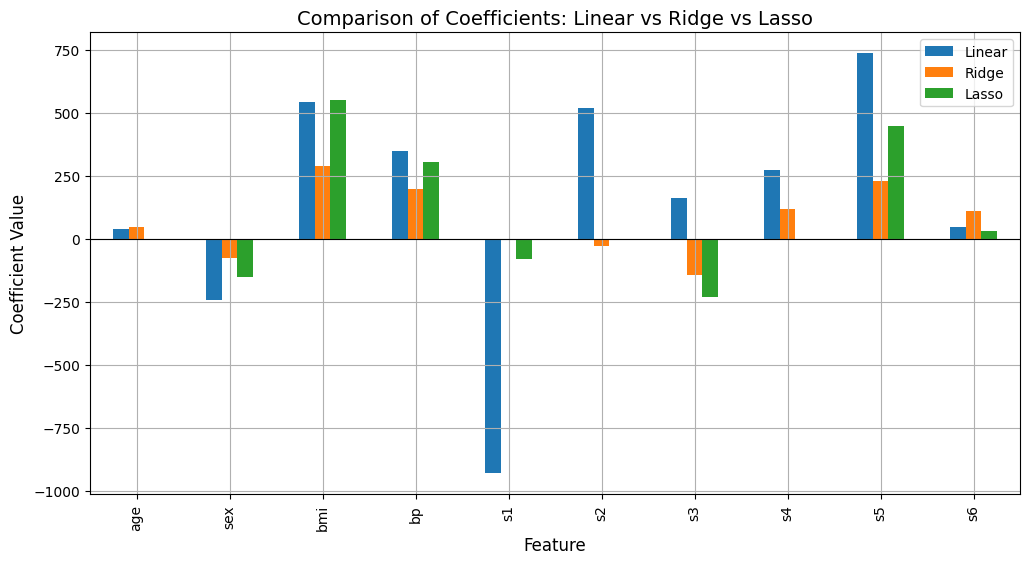

In [ ]:
# Your answer here
import pandas as pd
import matplotlib.pyplot as plt

# Collect coefficients from all models
coef_df = pd.DataFrame({
    "Linear": lin_reg.coef_,
    "Ridge": ridge_reg.coef_,
    "Lasso": lasso.coef_  # or lasso_cv.coef_
}, index=feature_names)

# Plot
coef_df.plot(kind="bar", figsize=(12, 6))
plt.title("Comparison of Coefficients: Linear vs Ridge vs Lasso", fontsize=14)
plt.ylabel("Coefficient Value", fontsize=12)
plt.xlabel("Feature", fontsize=12)
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(True)
plt.show()


In linear regression, since s1 has a very large negative coefficient, any increase in the value of s1 will sharply decrease the predicted disease progression. This strong sensitivity may reflect overfitting due to correlated features.

Among the three models, Lasso Regression exhibits the most pronounced reliance on the BMI feature.
This is because Lasso penalizes less informative features, shrinking their coefficients to zero, which makes BMI’s contribution relatively larger. In contrast, Ridge shrinks all coefficients more evenly, and Linear Regression distributes weight but can be unstable due to collinearity.

********************************************

**Task 3.2 (5 points):** Cross-validation involves dividing the available data into multiple subsets or folds to ensure that the model is evaluated on different parts of the data. This helps in obtaining a more accurate estimate of how the model would perform on unseen data. Compare the cross validation scores between Linear, Ridge, and Lasso regression models using a bar plot.

By cross validation, let us use k-fold cross validation, where $k=5$ (a typically used number), let us use 80% as training set and 20% as validation set.

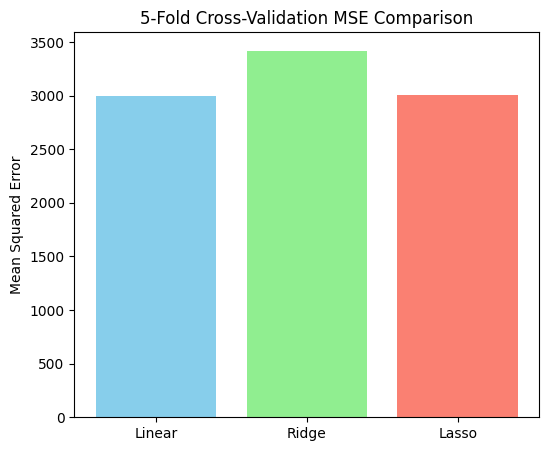

{'Linear': np.float64(2993.081310469331), 'Ridge': np.float64(3420.324074419442), 'Lasso': np.float64(3008.901906707106)}


In [ ]:
# Your answer here
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# Compute CV scores
models = {"Linear": lin_reg, "Ridge": ridge_reg, "Lasso": lasso}
cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_scores[name] = -np.mean(scores)

# Plot CV comparison
plt.figure(figsize=(6,5))
plt.bar(cv_scores.keys(), cv_scores.values(), color=['skyblue','lightgreen','salmon'])
plt.title("5-Fold Cross-Validation MSE Comparison")
plt.ylabel("Mean Squared Error")
plt.show()

print(cv_scores)


**Task 3.3 (5 points):** Conduct a grid search for both Lasso and Ridge regression models over the regularization parameter, and then visualize the differences in results obtained before and after the grid search using a bar plot.
- What are the obtained regularization strength parameters for both models?
- Did the grid search improve model performance?

In [ ]:
# Your answer here
from sklearn.model_selection import GridSearchCV
import numpy as np

# Ridge grid search
ridge_params = {"alpha": np.logspace(-3, 3, 20)}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring="neg_mean_squared_error")
ridge_grid.fit(X_train, y_train)

# Lasso grid search
lasso_params = {"alpha": np.logspace(-3, 1, 20)}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring="neg_mean_squared_error")
lasso_grid.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_["alpha"])
print("Best Ridge CV MSE:", -ridge_grid.best_score_)
print("Best Lasso alpha:", lasso_grid.best_params_["alpha"])
print("Best Lasso CV MSE:", -lasso_grid.best_score_)


Best Ridge alpha: 0.07847599703514611
Best Ridge CV MSE: 3122.3714692961894
Best Lasso alpha: 0.07847599703514611
Best Lasso CV MSE: 3125.3153072704586


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
import numpy as np

def cv_mse(model, X, y, k=5):
    # neg_mean_squared_error -> make positive and average
    return -cross_val_score(model, X, y, cv=k, scoring="neg_mean_squared_error").mean()

# baselines
lin_base   = LinearRegression()
ridge_base = Ridge(alpha=1.0)
lasso_base = Lasso(alpha=1.0, max_iter=10000)

# tuned models from your grid searches
ridge_tuned = ridge_grid.best_estimator_
lasso_tuned = lasso_grid.best_estimator_

results_cv = {
    "Linear (baseline)"     : cv_mse(lin_base,   X_train, y_train),
    "Ridge base (α=1)"      : cv_mse(ridge_base, X_train, y_train),
    "Ridge tuned"           : cv_mse(ridge_tuned, X_train, y_train),
    "Lasso base (α=1)"      : cv_mse(lasso_base, X_train, y_train),
    "Lasso tuned"           : cv_mse(lasso_tuned, X_train, y_train),
}
print(results_cv)


{'Linear (baseline)': np.float64(3143.015307427723), 'Ridge base (α=1)': np.float64(3639.4003323077027), 'Ridge tuned': np.float64(3122.3714692961894), 'Lasso base (α=1)': np.float64(3997.783751184155), 'Lasso tuned': np.float64(3125.3153072704586)}


In [ ]:
# fit tuned models on all training data and evaluate on the held-out test set
ridge_tuned.fit(X_train, y_train)
lasso_tuned.fit(X_train, y_train)

ridge_test_mse = mean_squared_error(y_test, ridge_tuned.predict(X_test))
lasso_test_mse = mean_squared_error(y_test, lasso_tuned.predict(X_test))

print({"Ridge tuned test MSE": ridge_test_mse,
       "Lasso tuned test MSE": lasso_test_mse})


{'Ridge tuned test MSE': 2859.76745853799, 'Lasso tuned test MSE': 2800.211333961947}


In [ ]:
from sklearn.model_selection import cross_val_predict

y_hat_cv_ridge = cross_val_predict(ridge_tuned, X_train, y_train, cv=5)
y_hat_cv_lasso = cross_val_predict(lasso_tuned, X_train, y_train, cv=5)

print("Ridge tuned CV MSE:", mean_squared_error(y_train, y_hat_cv_ridge))
print("Lasso tuned CV MSE:", mean_squared_error(y_train, y_hat_cv_lasso))


Ridge tuned CV MSE: 3121.0238697355135
Lasso tuned CV MSE: 3124.179537522361


For ridge regression, the MSE decreases, but for Lasso, the MSE increases.

### Question 4: Bias and Variance Tradeoff (12 points)

**Task 4.1 (5 points)** Describe the bias-variance tradeoff, how it affects model performance, and explain the relationship between model complexity and bias/variance. Use markdown cells for explanation.


Your answer here

**Task 4.2 (7 points):** Consider the Z dataset with input features X and target values y. Introduce polynomial features with degrees 5 to transform the input features into higher-degree polynomials.

To demonstrate the bias-variance tradeoff, fit the 3 types of regression models to the transformed dataset. Then, create line plots where the x-axis represents the polynomial degrees, and the y-axis represents the Mean Squared Error (MSE) for both the training and testing datasets. Compare the errors between these models.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.397e+03, tolerance: 2.145e+02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.091e+03, tolerance: 2.145e+02
  model = cd_fast.enet_coordinate_descent(


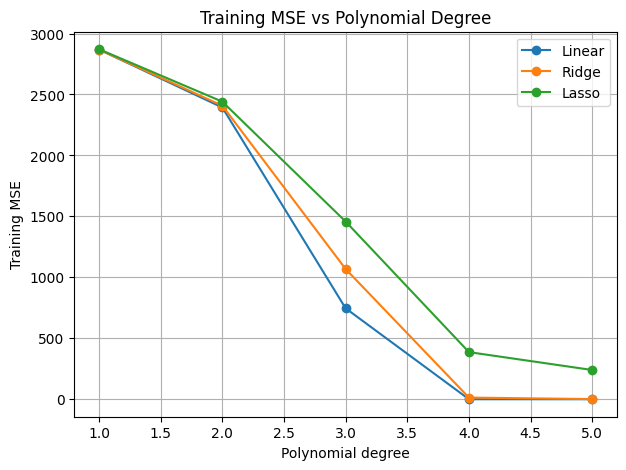

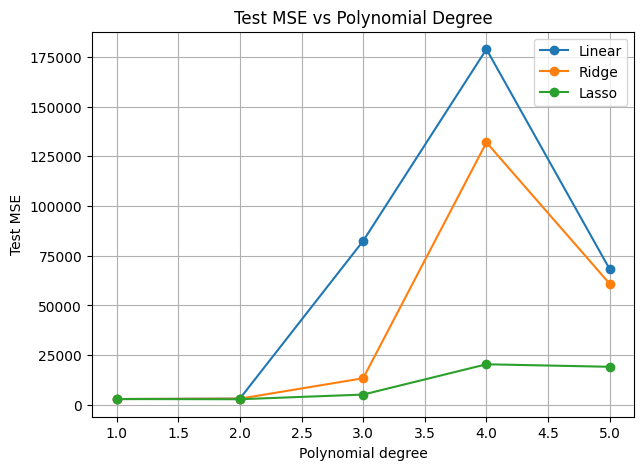

Training MSE:
          Linear    Ridge    Lasso
degree                           
1       2868.55  2868.57  2871.16
2       2393.14  2407.79  2440.79
3        745.62  1067.94  1457.23
4          0.00    13.37   386.44
5          0.00     1.34   239.63

Test MSE:
            Linear      Ridge     Lasso
degree                                
1         2900.19    2899.29   2887.47
2         3096.03    3075.00   2803.05
3        82446.05   13355.30   5147.54
4       178909.29  132003.67  20385.23
5        68178.08   60856.76  19122.35


In [ ]:
# Your answer here
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

degrees = range(1, 6)  # 1,2,3,4,5

# Use the best alphas you found (fallbacks if not defined)
ridge_alpha = (ridge_grid.best_params_["alpha"] if "ridge_grid" in globals() else 1.0)
lasso_alpha = (lasso_grid.best_params_["alpha"] if "lasso_grid" in globals() else 0.1)

models = {
    "Linear": LinearRegression(),
    "Ridge":  Ridge(alpha=ridge_alpha),
    "Lasso":  Lasso(alpha=lasso_alpha, max_iter=10000)
}

train_mse = {name: [] for name in models}
test_mse  = {name: [] for name in models}

for d in degrees:
    for name, base_model in models.items():
        pipe = Pipeline([
            ("poly",   PolynomialFeatures(degree=d, include_bias=False)),
            ("scale",  StandardScaler(with_mean=False)),  # safe for sparse/high-dim poly design
            ("model",  base_model)
        ])
        pipe.fit(X_train, y_train)
        yhat_tr = pipe.predict(X_train)
        yhat_te = pipe.predict(X_test)
        train_mse[name].append(mean_squared_error(y_train, yhat_tr))
        test_mse[name].append(mean_squared_error(y_test,  yhat_te))

# ---- Plot: TRAIN MSE vs degree ----
plt.figure(figsize=(7,5))
for name in models:
    plt.plot(list(degrees), train_mse[name], marker="o", label=name)
plt.xlabel("Polynomial degree")
plt.ylabel("Training MSE")
plt.title("Training MSE vs Polynomial Degree")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot: TEST MSE vs degree ----
plt.figure(figsize=(7,5))
for name in models:
    plt.plot(list(degrees), test_mse[name], marker="o", label=name)
plt.xlabel("Polynomial degree")
plt.ylabel("Test MSE")
plt.title("Test MSE vs Polynomial Degree")
plt.legend()
plt.grid(True)
plt.show()

# (optional) print the numeric tables
import pandas as pd
df_train = pd.DataFrame(train_mse, index=degrees); df_train.index.name="degree"
df_test  = pd.DataFrame(test_mse,  index=degrees); df_test.index.name="degree"
print("Training MSE:\n", df_train.round(2))
print("\nTest MSE:\n", df_test.round(2))


#### Z dataset (Classification)

For the last question, we will create a classification version of the Z dataset as follows:

Class 0: Denotes Z progression values that fall below the 50th percentile of the original target variable.

Class 1: Denotes Z progression values that surpass the 50th percentile of the original target variable.

In [ ]:
from sklearn.utils import shuffle

# Shuffle the data
X, y = shuffle(X, y, random_state=42)

# Create the target variable
y = np.where(y > np.percentile(y, 50), 1, 0)

In [ ]:
import numpy as np
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, RocCurveDisplay

# 1) Shuffle (reproducible)
X, y = shuffle(X, y, random_state=42)

# 2) Median split -> y_bin (0: ≤ median, 1: > median)
threshold = np.percentile(y, 50)
y_bin = (y > threshold).astype(int)        # ~50/50 classes

# 3) Train/test split (stratify to keep 50/50 in both)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)

# 4) Define models (all with scaling in a Pipeline)
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
])

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, random_state=42))
])

knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=7))
])

models = {"LogReg": logreg, "SVM-RBF": svm_rbf, "KNN": knn}

# 5) Fit + evaluate
def evaluate(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model.named_steps["clf"], "predict_proba") else model.decision_function(X_test)
    acc = accuracy_score(y_test, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary", zero_division=0)
    auc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name}")
    print(f"Accuracy: {acc:.3f} | Precision: {pr:.3f} | Recall: {rc:.3f} | F1: {f1:.3f} | ROC-AUC: {auc:.3f}")
    print("Confusion matrix:\n", cm)
    return {"acc": acc, "f1": f1, "auc": auc}

results = {name: evaluate(m, name) for name, m in models.items()}

# 6) Quick 5-fold CV (on training set) for each model using accuracy
for name, m in models.items():
    cv = cross_val_score(m, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name} 5-fold CV accuracy: {cv.mean():.3f} ± {cv.std():.3f}")



LogReg
Accuracy: 0.652 | Precision: 0.644 | Recall: 0.659 | F1: 0.652 | ROC-AUC: 0.787
Confusion matrix:
 [[29 16]
 [15 29]]

SVM-RBF
Accuracy: 0.719 | Precision: 0.702 | Recall: 0.750 | F1: 0.725 | ROC-AUC: 0.762
Confusion matrix:
 [[31 14]
 [11 33]]

KNN
Accuracy: 0.742 | Precision: 0.733 | Recall: 0.750 | F1: 0.742 | ROC-AUC: 0.788
Confusion matrix:
 [[33 12]
 [11 33]]
LogReg 5-fold CV accuracy: 0.776 ± 0.035
SVM-RBF 5-fold CV accuracy: 0.739 ± 0.053
KNN 5-fold CV accuracy: 0.737 ± 0.072


<Figure size 600x500 with 0 Axes>

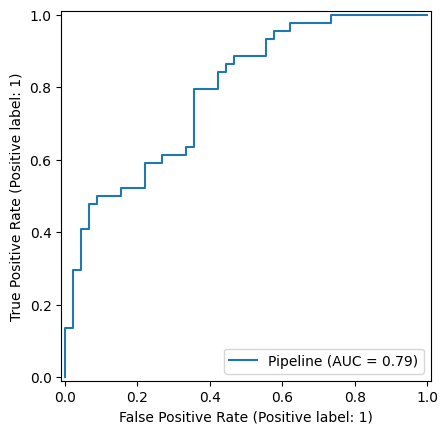

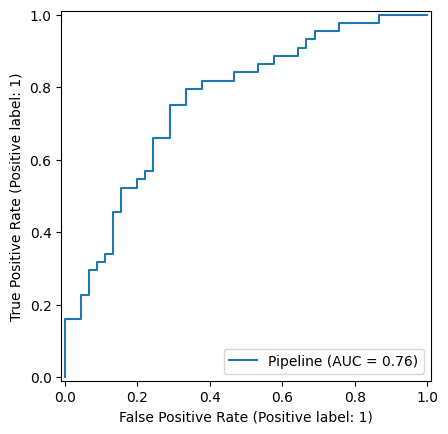

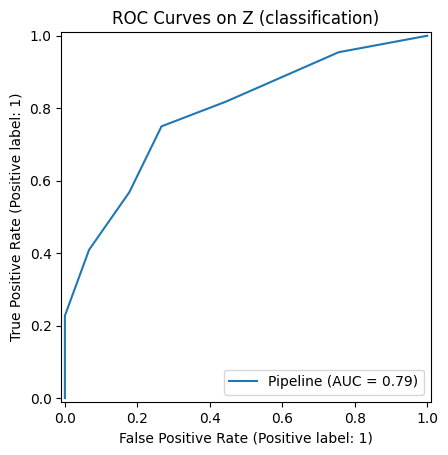

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
for name, m in models.items():
    m.fit(X_train, y_train)
    if hasattr(m.named_steps["clf"], "predict_proba"):
        RocCurveDisplay.from_estimator(m, X_test, y_test)
    else:
        RocCurveDisplay.from_estimator(m, X_test, y_test)  # works with decision_function too

plt.title("ROC Curves on Z (classification)")
plt.show()


### Question 5: Logistic Regression (20 points)


**Task 5.1 (2 points):** Implement the sigmoid function.    
**Task 5.2 (7 points):** Initialize the weights and biases to zeros and implement gradient descent.   
**Task 5.3 (6 points):** Implement the predict and predict_proba functions:
  - predict returns a single discrete category corresponding to the class that has been predicted.
  - predict_proba returns continuous values that represent the likelihood of each input belonging to each class.

In [ ]:
# Your answer here
import numpy as np

def sigmoid(z):
    # numerically stable sigmoid
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_epochs=2000, reg=0.0, fit_intercept=True):
        self.lr = lr
        self.n_epochs = n_epochs
        self.reg = reg              # L2 strength (0 = no reg)
        self.fit_intercept = fit_intercept
        self.w = None               # weights (p,)
        self.b = 0.0                # bias

    def _add_intercept(self, X):
        if not self.fit_intercept:
            return X
        return np.c_[np.ones((X.shape[0], 1)), X]

    def fit(self, X, y):
        """
        Gradient descent on the binary cross-entropy loss with optional L2.
        Initialize w and b to zeros as required.
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)

        n, p = X.shape
        if self.fit_intercept:
            # we keep b separate (no regularization on the intercept)
            self.w = np.zeros(p)
            self.b = 0.0
        else:
            self.w = np.zeros(p)

        for _ in range(self.n_epochs):
            # logits and probabilities
            z = X @ self.w + (self.b if self.fit_intercept else 0.0)
            p_hat = sigmoid(z)

            # gradients
            error = p_hat - y                               # (n,)
            grad_w = (X.T @ error) / n + self.reg * self.w  # L2 on weights only
            if self.fit_intercept:
                grad_b = error.mean()
                # update
                self.w -= self.lr * grad_w
                self.b -= self.lr * grad_b
            else:
                self.w -= self.lr * grad_w

        return self

    # 5.3: predict_proba and predict
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        z = X @ self.w + (self.b if self.fit_intercept else 0.0)
        return sigmoid(z)  # probability of class 1

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


**Task 5.4 (5 points):** Create an instance of a LogisticRegressionScratch model and train it using a new (80/20%) split of the classification dataset. Afterwards, calculate the accuracy, precision, recall, and F1 score (you can use available machine learning libraries).

In [ ]:
# Your answer here
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# fresh split for Q5
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y_bin, test_size=0.2, random_state=0, stratify=y_bin
)

# simple standardization helps GD a lot
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# train
model = LogisticRegressionScratch(lr=0.1, n_epochs=4000, reg=1e-3, fit_intercept=True)
model.fit(X_tr_s, y_tr)

# evaluate
y_pred = model.predict(X_te_s)
y_prob = model.predict_proba(X_te_s)

acc = accuracy_score(y_te, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="binary", zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 score:  {f1:.3f}")


Accuracy:  0.753
Precision: 0.750
Recall:    0.750
F1 score:  0.750
